# Basic Analysis for df_all_sel

This notebook loads `005380.csv` and `all_news.csv`, then builds `df_all_sel` and runs basic analysis/plots.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

BASE = Path("..").resolve()
DATA_DIR = BASE / "data" / "stock"

df_005380 = pd.read_csv(DATA_DIR / "005380.csv")
df_all = pd.read_csv(DATA_DIR / "all_news.csv")

df_005380.head(), df_all.head()

(         날짜      종가     최고가     최저가  전체 거래량  전체 거래 대금  개인_매수2_거래량  \
 0  20230102  157000  161000  154000     NaN       NaN      280053   
 1  20230103  159000  160500  156000     NaN       NaN      250812   
 2  20230104  160500  161000  157500     NaN       NaN      157126   
 3  20230105  159000  161500  158000     NaN       NaN      144863   
 4  20230106  159500  161500  157500     NaN       NaN      100822   
 
    개인_매수2_거래대금  개인_매도_거래량  개인_매도_거래대금  외국인_매수2_거래량  외국인_매수2_거래대금  외국인_매도_거래량  \
 0        44320     611614       96920       364564         57827      115058   
 1        39715     282990       44916       238331         37784      197661   
 2        25082     211612       33812       185164         29558      120053   
 3        23059     133848       21290       188021         29920      193128   
 4        16119     200296       32093       181548         29050      125883   
 
    외국인_매도_거래대금  기관계_매수2_거래량  기관계_매수2_거래대금  기관계_매도_거래량  기관계_매도_거래대금  
 0        18165     

In [2]:
df_all_sel = df_all[["stock_code", "published_dt", "title", "source_name"]].copy()
df_all_sel.head()

,stock_code,published_dt,title,source_name
0,247540,20260122,"22일, 외국인 코스닥에서 에코프로비엠(+7.68%), 에코프로(+10.41%) 등...",한국경제신문
1,247540,20260122,"[한경유레카 특징주] 에코프로비엠, 로봇관련 모멘텀으로 반등",한국경제신문
2,247540,20260122,"[장중수급포착] 에코프로비엠, 외국인/기관 동시 순매수… 주가 +8.18%",뉴스핌
3,247540,20250115,"15일, 코스닥 기관 순매수상위에 일반전기전자 업종 8종목",한국경제신문
4,247540,20250115,"[리포트 브리핑]에코프로비엠, '4Q24 Preview: 컨센서스 하회' 목표가 1...",뉴스핌


In [3]:
# Basic info
df_all_sel.info()

<class 'pandas.DataFrame'>
RangeIndex: 2861 entries, 0 to 2860
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   stock_code    2861 non-null   int64
 1   published_dt  2861 non-null   int64
 2   title         2859 non-null   str  
 3   source_name   2861 non-null   str  
dtypes: int64(2), str(2)
memory usage: 89.5 KB


In [4]:
# Missing values
df_all_sel.isna().sum()

stock_code      0
published_dt    0
title           2
source_name     0
dtype: int64

In [5]:
df_numeric = df_all_sel[df_all_sel["stock_code"].str.isnumeric()]
df_numeric.info()

AttributeError: Can only use .str accessor with string values, not integer

In [ ]:
# Convert date
df_numeric["published_dt"] = df_numeric["published_dt"].astype(str)
df_numeric["date"] = pd.to_datetime(df_numeric["published_dt"], errors="coerce", format="%Y%m%d")
df_numeric[["published_dt", "date"]].head()

,published_dt,date
0,20250117,2025-01-17
1,20250120,2025-01-20
2,20250122,2025-01-22
3,20250209,2025-02-09
4,20250224,2025-02-24


In [ ]:
# Date range
df_numeric["date"].min(), df_numeric["date"].max()

(Timestamp('2025-01-15 00:00:00'), Timestamp('2026-01-28 00:00:00'))

In [ ]:
# Top sources
df_numeric["source_name"].value_counts().head(15)

source_name
뉴스핌       58395
이데일리      36248
이투데이      26428
서울경제      26131
연합뉴스      22830
머니투데이     22763
한국경제신문    21534
Name: count, dtype: int64

## 뉴스별 기본 시각화


### 원본 시각화

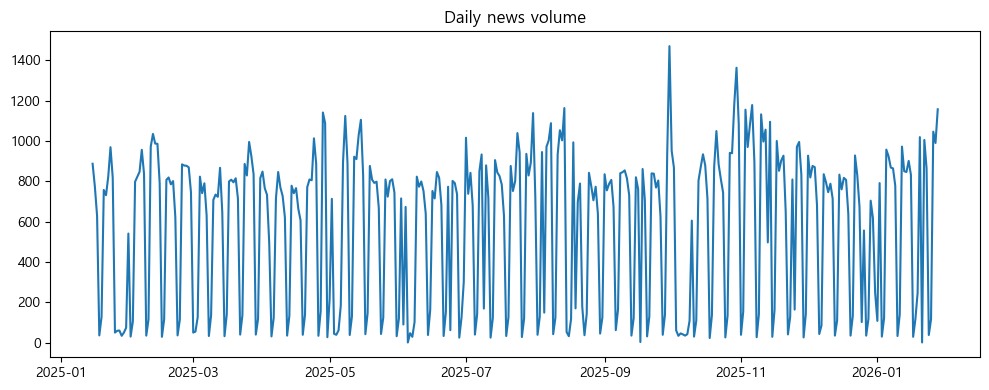

In [ ]:
# News volume over time (daily)
daily = df_numeric.groupby("date").size().rename("count").reset_index()
plt.figure(figsize=(10, 4))
plt.plot(daily["date"], daily["count"])
plt.title("Daily news volume")
plt.tight_layout()
plt.show()

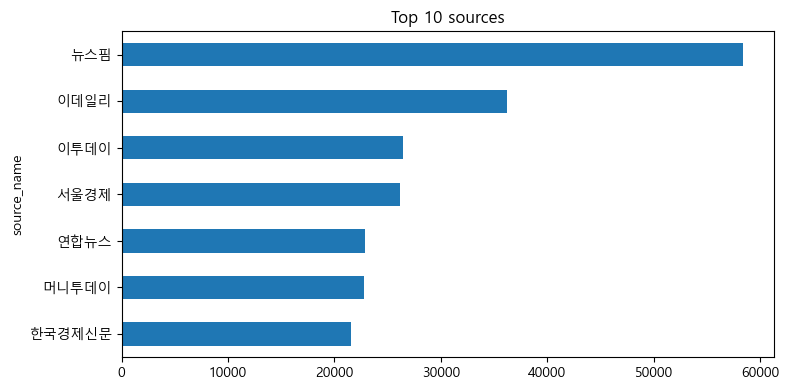

In [ ]:
# Top sources bar chart
top_sources = df_numeric["source_name"].value_counts().head(10)
plt.figure(figsize=(8, 4))
top_sources[::-1].plot(kind="barh")
plt.title("Top 10 sources")
plt.tight_layout()
plt.show()

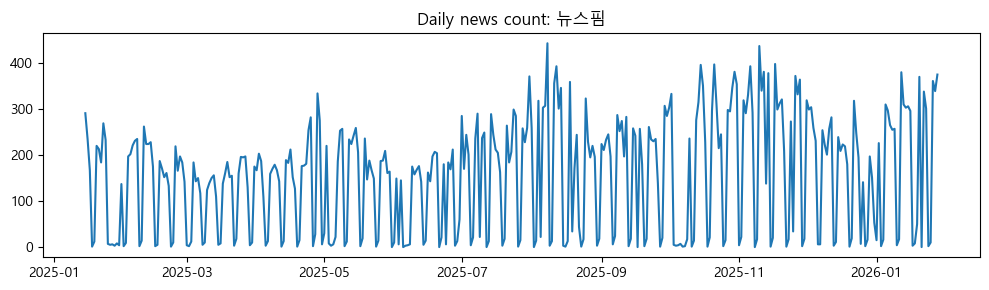

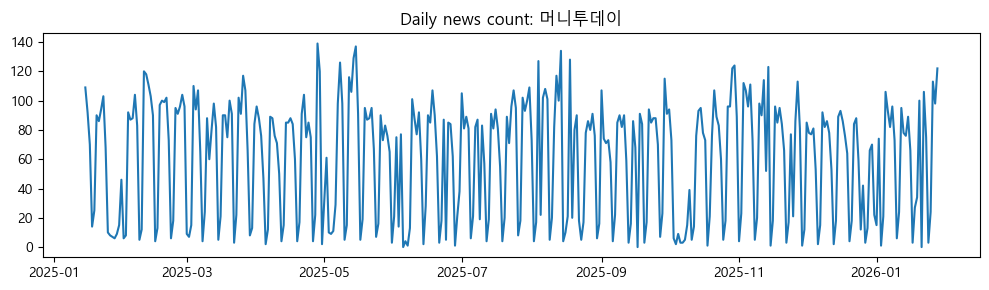

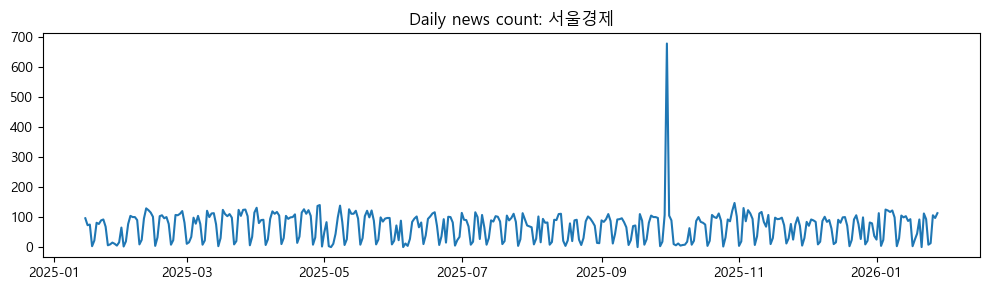

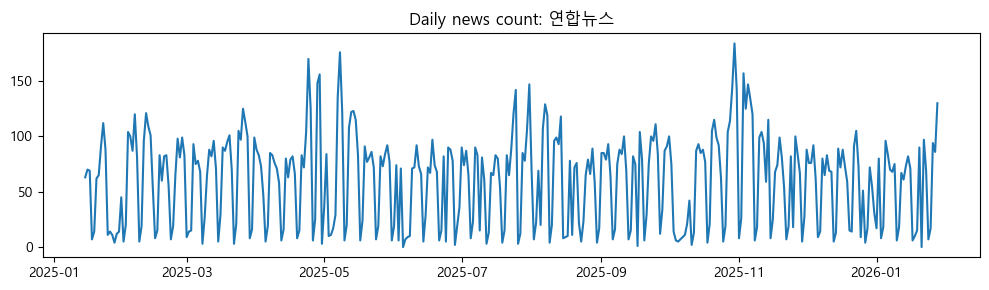

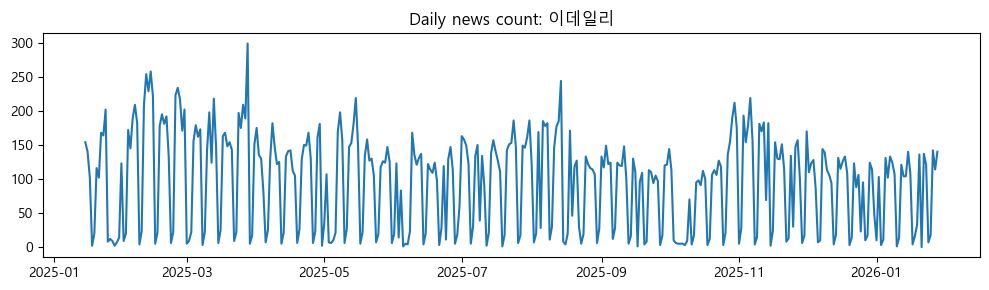

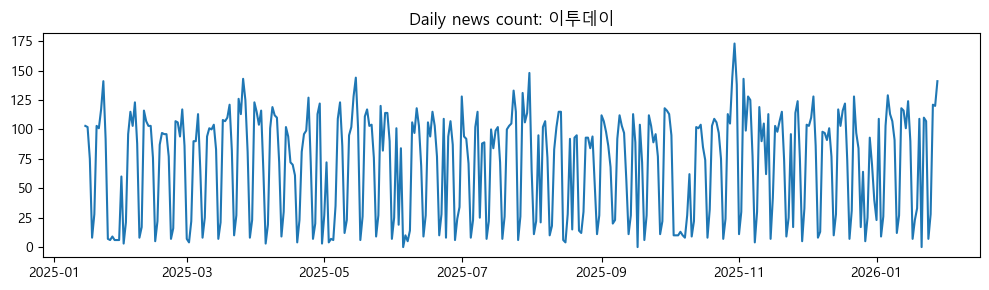

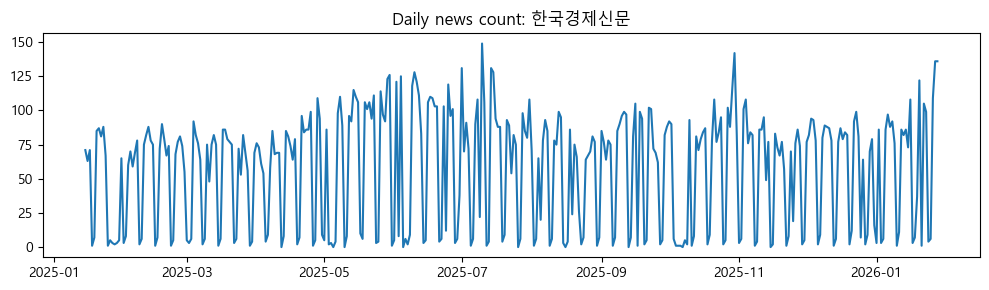

In [ ]:
# Daily news count by source (top N) - one plot per source
top_n = 8
top_sources = df_numeric["source_name"].value_counts().head(top_n).index
df_top = df_numeric[df_numeric["source_name"].isin(top_sources)].copy()

daily_source = (
    df_top.groupby(["date", "source_name"]).size().rename("count").reset_index()
)

pivot = daily_source.pivot(index="date", columns="source_name", values="count").fillna(0)

for col in pivot.columns:
    plt.figure(figsize=(10, 3))
    plt.plot(pivot.index, pivot[col], color="#1f77b4")
    plt.title(f"Daily news count: {col}")
    plt.tight_layout()
    plt.show()


In [ ]:
df_numeric[df_numeric["source_name"]=="서울경제"].assign(date=pd.to_datetime(df_numeric["published_dt"].astype(str), format="%Y%m%d", errors="coerce")).groupby("date").size().loc[lambda s: s>200]


date
2025-09-30    678
dtype: int64

### 이상치 발견후 필터링

In [ ]:
pat = (
    r"^\[정오\s*시황\]"                                   # [정오 시황]
    r"|"
    r"^(?:오전|오후)\s*\d{1,2}:\d{2}\s*(?:현재\s*)?"
    r"(?:코스피|코스닥).*(?:매수우위|매도우위|매수강세|매도강세)"
    r"|"
    r"^\[(?:포토|인사|오늘의\s*IR|한경유레카)\]"          # 대괄호 메타
    r"|"
    r"<\s*(?:유|코)\s*>"                                  # <유>, <코>
    r"|"
    r"^오늘의\s*메모"                                     # 오늘의 메모
)

mask = ~df_numeric["title"].str.contains(pat, regex=True, na=False)
df_filtered = df_numeric[mask]

In [ ]:
df_filtered["published_dt"] = pd.to_datetime(
    df_filtered["published_dt"],
    errors="coerce"
)

In [ ]:
target = pd.to_datetime("2025-09-30")
df_filtered[
    (df_filtered["published_dt"].dt.date == target.date()) &
    (df_filtered["source_name"] == "서울경제")
].shape

(87, 5)

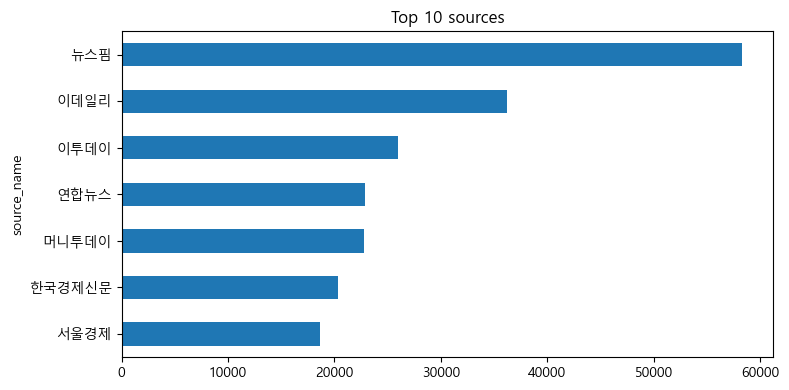

In [ ]:
# Top sources bar chart
top_sources = df_filtered["source_name"].value_counts().head(10)
plt.figure(figsize=(8, 4))
top_sources[::-1].plot(kind="barh")
plt.title("Top 10 sources")
plt.tight_layout()
plt.show()

In [ ]:
df_filtered.to_csv("df_filtered.csv", index=False, encoding="utf-8-sig")


In [ ]:
df_filtered["title"].str.contains(
    r"오후\s*2:00\s*현재\s*코스닥은",
    regex=True,
    na=False
).sum()

np.int64(0)

## ㅇㅇ